## Imports

In [21]:
import numpy as np
import math
import matplotlib.pyplot as plt

import spinSimulations.spin as s
from spinSimulations.solver_H import amplitude
from spinSimulations.solver_L import *
from spinSimulations.plotter import *
from scipy.linalg import expm, null_space
from scipy.integrate import solve_ivp

## Global setter

In [22]:
# THESE ARE GLOBAL VARS
ss_S = op_S = ppms_S = Js_S = None
ss_C = op_C = ppms_C = Js_C = None

# THIS IS A SETTER FOR THEM
def set_up_spin_system():
    ###################################################
    ### Set up spin system of the free substrate ###
    global ss_S, op_S
    global ppms_S, Js_S
    #global idx_H, idx_D, idx_X
    
    Js_S = np.array(
        [[0]]
    )

    ppms_S = np.array([300])*1e-6

    n_spins = 1

    nuclei_list = ["15N"]

    ss_S = s.System(
        n_spins, nuclei_list=nuclei_list.copy(),
        is_sparse=False,
        Js=Js_S.copy(),
        ppms=ppms_S.copy(),
    )
    
    op_S = ss_S.op

    ###################################################
    ### Set up spin system of the SABRE complex
    global ss_C, op_C
    global ppms_C, Js_C
    #global idx_H, idx_D, idx_X
    
    Js_C = np.array(
            [[0, -7.7, -21],
            [0, 0, 0],
            [0, 0, 0]]
        )

    ppms_C = np.array([-22,-22,250])*1e-6

    n_spins = 3

    nuclei_list = 2 * ["1H"] + ["15N"]

    ss_C = s.System(
        n_spins, nuclei_list=nuclei_list.copy(),
        is_sparse=False,
        Js=Js_C.copy(),
        ppms=ppms_C.copy(),
    )

    op_C = ss_C.op

T1_S = np.array([10])
T1_C = np.array([3,3,5])

set_up_spin_system()

In [23]:
#Density matrix of pure pH2
rho_pH2=np.array([[0,0,0,0],[0,0.5,-0.5,0],[0,-0.5,0.5,0],[0,0,0,0]]) 

#Initialization of the composite system matrix
def SABRE_SO(ss_S, ss_C, B0, kd, W):
    #Generate partial trace superoperator
    Tr = part_trace_SO(ss_S,ss_C)
  
    #Generate Kronecker product superoperator
    Kron = kron_SO(ss_S,ss_C,rho_pH2)

    #Calculate relaxation superoperator of the substrate
    R_S = relax_phenom_SO(ss_S, T1_S)
    
    #Calculate Hamiltonian of the substrate
    ham_S = ss_S.build_ham_lab(field=B0, ZULF = True)

    #Generate the Liouvillian of the substrate
    L_S = -1j*comm_SO(ham_S)+R_S

    #Calculate relaxation superoperator of the complex
    R_C = relax_phenom_SO(ss_C, T1_C)

    #Calculate Hamiltonian superoperator of the complex
    ham_C = ss_C.build_ham_lab(field=B0, ZULF = True)

    #Generate Liouvillian of the complex
    L_C = -1j*comm_SO(ham_C)+R_C

    #Generate SABRE matrix for the composite system
    M = np.block([[L_S-kd*W*np.eye(ss_S.get_spin_dim()**2), kd*Tr],[kd*W*Kron, L_C-kd*np.eye(ss_C.get_spin_dim()**2)]])

    return M


## Field dependence

In [112]:
kd = 40
W = 0.1
B0 = np.linspace(-5e-6,5e-6,200)

P_1 = np.empty(len(B0))
obs = ss_S.pol_level(0)

for i,b in enumerate(B0):
    #Initialization of the composite system matrix
    M_SABRE = SABRE_SO(ss_S, ss_C, b, kd, W)
    
    #Calculate the steady state of the system
    sigma = null_space(M_SABRE)                         #Calculate the null space of the coefficient matrix
    sigma = sigma[:ss_S.get_spin_dim()**2]
    sigma = vec2mat(sigma)

    #Normalize the steady-state density operator
    sigma = sigma / np.trace(sigma)

    #Calculate the polarization level
    P_1[i]=np.real(amplitude(obs, sigma))

Text(0.5, 1.0, '$\\mathit{k}_\\mathrm{d}$=40 s$^{-1}; $$\\mathit{W}_\\mathrm{a}$=0.1 s$^{-1}$')

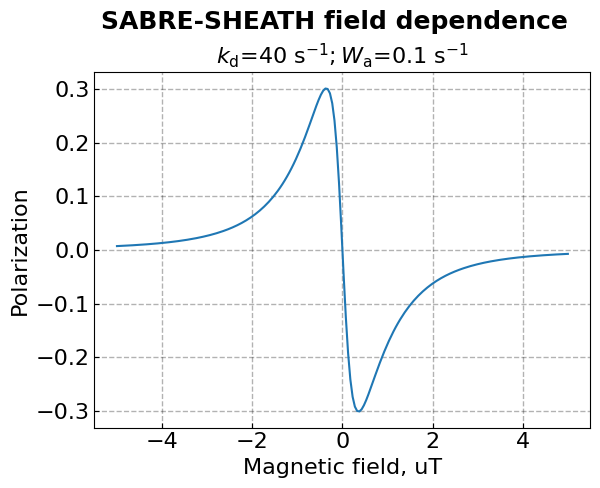

In [113]:
fig, (ax1) = plt.subplots(nrows=1)
fig.subplots_adjust(top=0.85)

ax1.plot(B0*1e+6,P_1)

ax1.tick_params( axis='both', which='major', labelsize=16,direction='in')

ax1.grid(axis="x", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")
ax1.grid(axis="y", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")

ax1.set_xlabel('Magnetic field, uT',fontsize=16)
ax1.set_ylabel('Polarization',fontsize=16)

fig.suptitle('SABRE-SHEATH field dependence', fontsize=18, fontweight='bold')
#ax1.set_title(r'$\mathit{k}_d$='+f"{kd}"+r', s$^{-1}$'+r'$\mathit{W_a}$'+f"={W}, s",fontsize=16)
ax1.set_title(r'$\mathit{k}_\mathrm{d}$='+f"{kd}"+r' s$^{-1}; $'+
              r'$\mathit{W}_\mathrm{a}$='+f"{W}"+r' s$^{-1}$',fontsize=16)


## Polarization build-up

In [26]:
# Set magnetic field for polariztion transfer in T
B0 = 0.3*1e-6

#Initialization of the composite system matrix
M_SABRE = SABRE_SO(ss_S, ss_C, B0, kd, W)

rho_S=np.eye(ss_S.get_spin_dim(), dtype = np.complex128) #Non polarized density matrix for substrate
rho_S=rho_S/np.trace(rho_S)
rho_C=np.eye(ss_C.get_spin_dim(), dtype = np.complex128)  #Non polarized density matrix for complex
rho_C=rho_C/np.trace(rho_C)
#Density matrices -> concentration normalized density matrices
S_conc=1
C_conc=1*W
sigma_S = S_conc*rho_S 
sigma_C = C_conc*rho_C 
sigma_S = mat2vec(sigma_S)
sigma_C = mat2vec(sigma_C)
#Density matrix of the composite system
sigma_0 = np.hstack([sigma_S, sigma_C])

# Generate the observables (z-polarization)
obs_S = ss_S.pol_level(0)
obs_S = mat2vec(obs_S)
obs_C = ss_C.pol_level(2)
obs_C = mat2vec(obs_C)

In [27]:
#Calculation with numerical integration
def rhs(t,y): return M_SABRE @ y
t_start=0
t_end=10
sol=solve_ivp(rhs,[0,10],sigma_0,t_eval=np.linspace(t_start,t_end,2000))

#Calculate the polarization level
P_S=amplitude_v(obs_S, sol.y[:ss_S.get_spin_dim()**2,:]) ## 15N polarization in the substrate 
P_C=amplitude_v(obs_C, sol.y[ss_S.get_spin_dim()**2:ss_S.get_spin_dim()**2+ss_C.get_spin_dim()**2,:]) ## 15N polarization in the substrate 

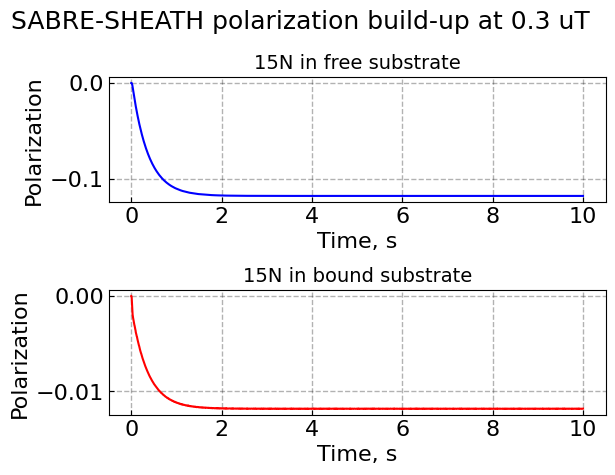

In [28]:
fig, (ax1) = plt.subplots(nrows=2)

ax1[0].plot(sol.t,P_S, 'b')
ax1[0].set_title("15N in free substrate",fontsize=14)
ax1[1].plot(sol.t,P_C, 'r')
ax1[1].set_title("15N in bound substrate",fontsize=14)
for i in range(2):
    ax1[i].set_xlabel('Time, s',fontsize=16)

    ax1[i].set_ylabel('Polarization',fontsize=16)

    ax1[i].tick_params( axis='both', which='major', labelsize=16,direction='in')

    ax1[i].grid(axis="x", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")
    ax1[i].grid(axis="y", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")

fig.suptitle(f"SABRE-SHEATH polarization build-up at {B0*1e+6} uT" + r'$\mathit{k}_\mathrm{d}$='+f"{kd}"+r' s$^{-1}; $'+
              r'$\mathit{W}_\mathrm{a}$='+f"{W}"+r' s$^{-1}$',fontsize=18)
fig.suptitle('SABRE-SHEATH field dependence', fontsize=18, fontweight='bold')

plt.tight_layout()

## 2D dependences

In [29]:
kd = np.geomspace(1,300,100)
W = 0.1
B0 = np.linspace(0,3e-6,100)

P_2 = np.zeros([len(B0),len(kd)])
obs = ss_S.pol_level(0)

for i1,k in enumerate(kd):
    for i2,b in enumerate(B0):
        #Set the magnetic field 
        M_SABRE = SABRE_SO(ss_S, ss_C, b, k, W)
        
        #Calculate the steady state of the system
        sigma = null_space(M_SABRE)                         #Calculate the null space of the coefficient matrix
        sigma = sigma[:ss_S.get_spin_dim()**2]
        sigma = vec2mat(sigma)

        #Normalize the steady-state density operator
        sigma = sigma / np.trace(sigma)

        #Calculate the polarization level
        P_2[i1,i2]=np.real(amplitude(obs, sigma))

c:\Users\Vitaly\.conda\envs\SpinSym_env\Lib\site-packages\spinsimulations-0.1-py3.12.egg\spinSimulations\plotter.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


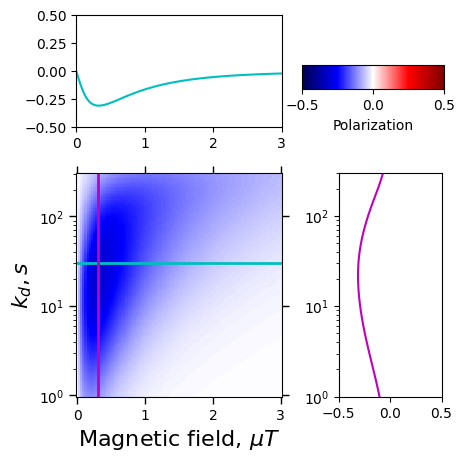

In [30]:
X,Y,Z=B0*1e+6,kd,P_2
x_axis = {"title": r'Magnetic field, $\mathit{\mu} T$',"scale": "linear", "slice": 0.3}
y_axis = {"title": r'$\mathit{k_d}, s$',"scale": "log", "slice": 30}
z_range=0.5
plot_2D_with_slices(X,Y,Z,z_range,x_axis=x_axis,y_axis=y_axis)

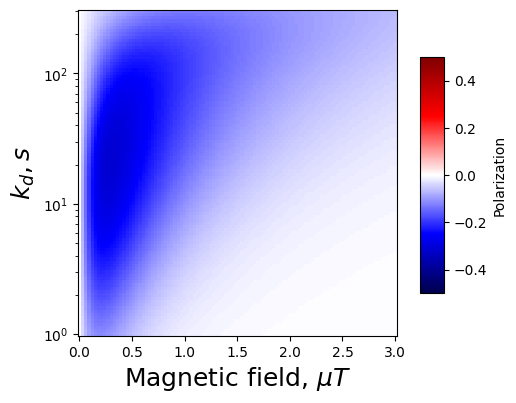

In [31]:
X,Y,Z=B0*1e+6,kd,P_2
x_axis = {"title": r'Magnetic field, $\mathit{\mu} T$',"scale": "linear"}
y_axis = {"title": r'$\mathit{k_d}, s$',"scale": "log"}
z_range=0.5
plot_2D(X,Y,Z,z_range,x_axis=x_axis,y_axis=y_axis)

## Coherent Stuff

### Constant field

In [32]:
# Set magnetic field for polariztion transfer in T
B0 = 0.1*1e-6

#Calculate Hamiltonian of the complex
ham_C = ss_C.build_ham_lab(field=B0, ZULF = True)

#Generate the Liouvillian of the complex
L_C = -1j*comm_SO(ham_C)

rho_C=ss_C.singlet(0, 1)
#Density matrices -> concentration normalized density matrices
sigma_C = C_conc*rho_C 
sigma_C = mat2vec(sigma_C)

# Generate the observables
obs_C = ss_C.pol_level(2)
obs_C = mat2vec(obs_C)

In [33]:
#Calculation with matrix exponent
N_steps = 1000   # Define the number of steps for the simulation
dt = 1/1000  # Define the time step for tthe simulation (in unit of second)
P1 = np.empty(N_steps) # Apply for memory for storing the Frquency domain data
U_evol = expm(L_C*dt)
for n in range(N_steps):

    P1[n]=amplitude_v(obs_C,sigma_C)
    sigma_C = U_evol@sigma_C # Evolve the system for dt

t = np.linspace(0,N_steps*dt,N_steps)

In [34]:
#Calculation with SciPy solver
sigma_C = C_conc*rho_C 
sigma_C = mat2vec(sigma_C)
#Calculation with numerical integration
def rhs(t,y): return L_C @ y
t_start=0
t_end=1
sol=solve_ivp(rhs,[t_start,t_end],sigma_C,t_eval=np.linspace(t_start,t_end,2000))

#Calculate the polarization level
P_C=amplitude_v(obs_C, sol.y) ## 15N polarization in the substrate 

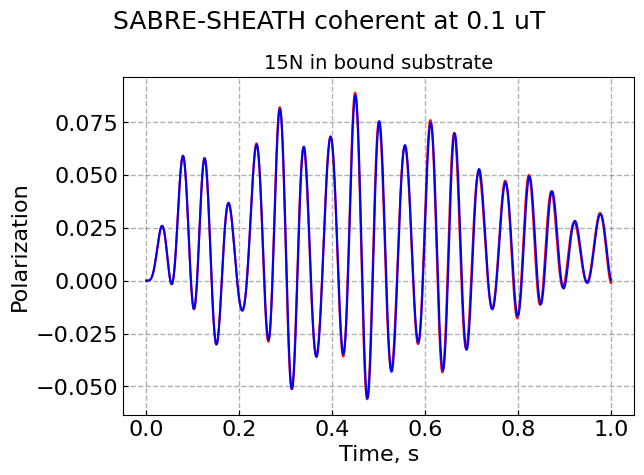

In [35]:
fig, (ax1) = plt.subplots(nrows=1)


ax1.plot(sol.t,P_C, 'r')

ax1.plot(t,P1, 'b')
ax1.set_title("15N in bound substrate",fontsize=14)

ax1.set_xlabel('Time, s',fontsize=16)

ax1.set_ylabel('Polarization',fontsize=16)

ax1.tick_params( axis='both', which='major', labelsize=16,direction='in')

ax1.grid(axis="x", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")
ax1.grid(axis="y", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")

fig.suptitle(f"SABRE-SHEATH coherent at {B0*1e+6:.1f} uT",fontsize=18)
plt.tight_layout()

### Two alternating fields

In [36]:
rho_C=ss_C.singlet(0, 1)
#Density matrices -> concentration normalized density matrices
sigma_C = C_conc*rho_C 
sigma_C = mat2vec(sigma_C)

# Generate the observables
obs_C = ss_C.pol_level(2)
obs_C = mat2vec(obs_C)

#Sampling the applied magnetic field in unit of uT
Blow = 0.2*1e-6
Bhigh = 50*1e-6

t_low=3e-2
t_high=1e-1

cycle_duration = t_low + t_high

def single_cycle(t):
    if t <= t_low:
        B0 = Blow
    else: 
        B0 = Bhigh
    #Calculate Hamiltonian of the complex
    ham_C = ss_C.build_ham_lab(field=B0, ZULF = True)
    #Generate the Liouvillian of the complex
    L_C = -1j*comm_SO(ham_C)
    return L_C

def alt_SABRE(t):
    t_cycle = t % cycle_duration
    return single_cycle(t_cycle)

In [37]:
#Calculation with SciPy solver
sigma_C = C_conc*rho_C 
sigma_C = mat2vec(sigma_C)
#Calculation with numerical integration
def rhs(t,y): 
    return alt_SABRE(t) @ y

t_start=0
t_end=1.5

sol=solve_ivp(rhs,[t_start,t_end],sigma_C,t_eval=np.linspace(t_start,t_end,1000),method="RK23")


#Calculate the polarization level
P_C=amplitude_v(obs_C, sol.y) ## 15N polarization in the substrate 

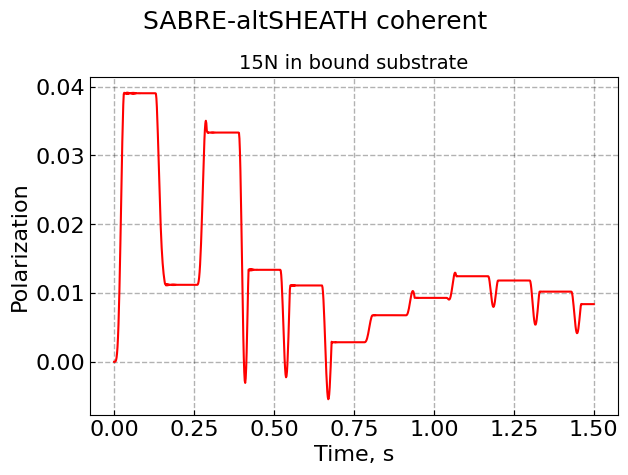

In [38]:
fig, (ax1) = plt.subplots(nrows=1)


ax1.plot(sol.t,P_C, 'r')

#ax1.plot(t,P1, 'b')
ax1.set_title("15N in bound substrate",fontsize=14)

ax1.set_xlabel('Time, s',fontsize=16)

ax1.set_ylabel('Polarization',fontsize=16)

ax1.tick_params( axis='both', which='major', labelsize=16,direction='in')

ax1.grid(axis="x", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")
ax1.grid(axis="y", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")

fig.suptitle(f"SABRE-altSHEATH coherent",fontsize=18)
plt.tight_layout()

In [39]:
# Set magnetic field for polariztion transfer in T
B0 = 0.3*1e-6
kd = 20
W = 0.1

rho_S=np.eye(ss_S.get_spin_dim(), dtype = np.complex128) #Non polarized density matrix for substrate
rho_S=rho_S/np.trace(rho_S)
rho_C=np.eye(ss_C.get_spin_dim(), dtype = np.complex128)  #Non polarized density matrix for complex
rho_C=rho_C/np.trace(rho_C)
#Density matrices -> concentration normalized density matrices
S_conc=1
C_conc=1*W
sigma_S = S_conc*rho_S 
sigma_C = C_conc*rho_C 
sigma_S = mat2vec(sigma_S)
sigma_C = mat2vec(sigma_C)
#Density matrix of the composite system
sigma_0 = np.hstack([sigma_S, sigma_C])

# Generate the observables
obs_S = ss_S.pol_level(0)
obs_S = mat2vec(obs_S)
obs_C = ss_C.pol_level(2)
obs_C = mat2vec(obs_C)

#Sampling the applied magnetic field in unit of uT
Blow = 0.5*1e-6
Bhigh =50*1e-6

t_low=0.01
t_high=0.032

cycle_duration = t_low + t_high
N_cycles = 200


In [40]:
#Calculation with matrix exponent
sigma_0 = np.hstack([sigma_S, sigma_C])

steps_per_cycle = 2000
dt = cycle_duration/steps_per_cycle
P_S_alt = np.empty(N_cycles*steps_per_cycle) # Apply for memory for storing the Frquency domain data
P_S = np.empty(N_cycles*steps_per_cycle) # Apply for memory for storing the Frquency domain data

U_evol_low = expm(SABRE_SO(ss_S, ss_C, Blow, kd, W)*dt)
U_evol_high = expm(SABRE_SO(ss_S, ss_C, Bhigh, kd, W)*dt)

for n in range(N_cycles):
    for m in range(steps_per_cycle):
        t_cycle = m*dt
        if t_cycle <= t_low:
            U_evol = U_evol_low
        else: 
            U_evol = U_evol_high      
        sigma_0 = U_evol@sigma_0 # Evolve the system for dt
        P_S_alt[n*steps_per_cycle+m]=amplitude_v(obs_S,sigma_0[:ss_S.get_spin_dim()**2])

sigma_0 = np.hstack([sigma_S, sigma_C])
U_evol = expm(SABRE_SO(ss_S, ss_C, B0, kd, W)*dt)
for n in range(N_cycles):
    for m in range(steps_per_cycle):    
        sigma_0 = U_evol@sigma_0 # Evolve the system for dt
        P_S[n*steps_per_cycle+m]=amplitude_v(obs_S,sigma_0[:ss_S.get_spin_dim()**2])

t_list = np.linspace(0,N_cycles*cycle_duration,N_cycles*steps_per_cycle)

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

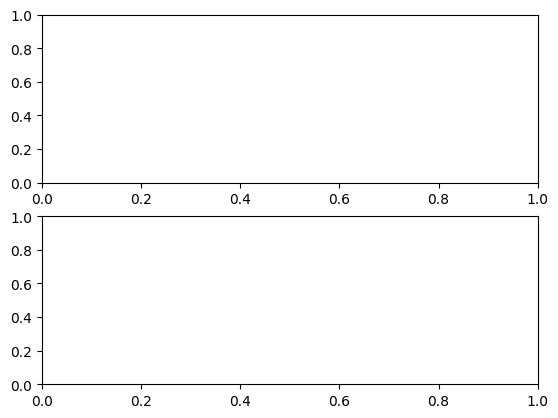

In [41]:
fig, (ax1) = plt.subplots(nrows=2)

ax1.plot(t_list,P_S_alt, 'b')
ax1.set_title("15N alt SHEATH",fontsize=14)
ax1.plot(t_list,P_S, 'r')

ax1.set_xlabel('Time, s',fontsize=16)

ax1.set_ylabel('Polarization',fontsize=16)

ax1.tick_params( axis='both', which='major', labelsize=16,direction='in')

ax1.grid(axis="x", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")
ax1.grid(axis="y", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")

fig.suptitle(f"SABRE-SHEATH polarization build-up" ,fontsize=18)
plt.tight_layout()